# Project 3 — Early Warning System for Sepsis (PhysioNet 2019)
## Notebook 04 — Calibration + Early Warning Policy + Lead-time & Alarm Burden

**Goal**
Convert a strong ML model into a clinically meaningful **early warning system** by:
1) using **OOF probabilities** (from Notebook 03),
2) calibrating probabilities properly,
3) defining an **alert policy** (not just row-level classification),
4) selecting thresholds with **alarm burden vs lead-time** tradeoffs.

**Inputs**
- `results/oof_predictions.parquet` (from Notebook 03)
- `results/patient_events.parquet` (from Notebook 01)

**Outputs**
- `results/oof_with_calibration.parquet`
- `results/calibration_report.json`
- `results/threshold_sweep_policyA.csv`
- figures in `figures/` (reliability + tradeoff + lead-time)

**Key principle**
Calibration and policy must be done on **patient-grouped** predictions to avoid optimistic bias.


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

pd.set_option("display.max_columns", 200)

# -------------------------
# Paths (EDIT THIS ONCE)
# -------------------------
DATA_ROOT = Path(r"F:\Project 3 Folder\project 3--ews")

RESULTS_DIR = DATA_ROOT / "results"
FIG_DIR = DATA_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

IN_OOF = RESULTS_DIR / "oof_predictions.parquet"
IN_EVENTS = RESULTS_DIR / "patient_events.parquet"

OUT_OOF_CAL = RESULTS_DIR / "oof_with_calibration.parquet"
OUT_CAL_REPORT = RESULTS_DIR / "calibration_report.json"
OUT_SWEEP = RESULTS_DIR / "threshold_sweep_policyA.csv"

print("OOF exists:", IN_OOF.exists(), IN_OOF)
print("Events exists:", IN_EVENTS.exists(), IN_EVENTS)


OOF exists: True F:\Project 3 Folder\project 3--ews\results\oof_predictions.parquet
Events exists: True F:\Project 3 Folder\project 3--ews\results\patient_events.parquet


### 1) Load OOF predictions + patient events
- OOF may contain multiple `model_name` values (e.g., `hgb`, `logreg`).
- Pick one model to calibrate + build policy on.


In [3]:
oof = pd.read_parquet(IN_OOF)
events = pd.read_parquet(IN_EVENTS)

req_oof = {"patient_id", "ICULOS", "y", "p_oof", "fold_id", "model_name"}
missing = req_oof - set(oof.columns)
assert not missing, f"OOF missing columns: {missing}"

req_ev = {"patient_id", "sepsis_any", "event_iculos"}
missing2 = req_ev - set(events.columns)
assert not missing2, f"Events missing columns: {missing2}"

oof = oof.sort_values(["patient_id", "ICULOS"]).reset_index(drop=True)

print("OOF rows:", len(oof), "patients:", oof["patient_id"].nunique())
print("Models in OOF:", sorted(oof["model_name"].unique().tolist()))
oof.head()


OOF rows: 38290 patients: 493
Models in OOF: ['hgb', 'logreg']


,patient_id,ICULOS,y,p_oof,fold_id,model_name
0,p000214,2,0,1.080546e-15,4,logreg
1,p000214,2,0,2.495916e-04,4,hgb
2,p000214,3,0,1.332876e-19,4,logreg
3,p000214,3,0,2.407218e-04,4,hgb
4,p000214,4,0,8.988509e-21,4,logreg


In [4]:
# Choose which model to use in this notebook
# If you produced multiple models in Notebook 03, we auto-pick the one with best OOF AUPRC (row-level).
from sklearn.metrics import average_precision_score

model_scores = []
for m in sorted(oof["model_name"].unique().tolist()):
    sub = oof[oof["model_name"] == m]
    if sub["y"].nunique() < 2:
        score = np.nan
    else:
        score = average_precision_score(sub["y"].values.astype(int), sub["p_oof"].values.astype(float))
    model_scores.append((m, float(score) if score == score else np.nan))

print("OOF AUPRC by model:", model_scores)

BEST_MODEL_NAME = max(model_scores, key=lambda x: (x[1] if x[1]==x[1] else -1))[0]
# Or hardcode, e.g.: BEST_MODEL_NAME = "hgb"

df = oof[oof["model_name"] == BEST_MODEL_NAME].copy()
df = df.merge(events[["patient_id", "sepsis_any", "event_iculos"]], on="patient_id", how="left")

assert df["sepsis_any"].notna().all(), "Some patients in OOF not found in patient_events.parquet"

df = df.sort_values(["patient_id", "ICULOS"]).reset_index(drop=True)

print("Using model:", BEST_MODEL_NAME)
print("Rows:", len(df), "Patients:", df["patient_id"].nunique())


OOF AUPRC by model: [('hgb', 0.1288055734449206), ('logreg', 0.09986802846004503)]
Using model: hgb
Rows: 19145 Patients: 493


### 2) Baseline (uncalibrated) row-level performance

In [5]:
y = df["y"].astype(int).values
p = df["p_oof"].astype(float).values

auroc = roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan
auprc = average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan
brier = brier_score_loss(y, p)

print(f"Row-level OOF AUROC: {auroc:.4f}")
print(f"Row-level OOF AUPRC: {auprc:.4f}")
print(f"Brier (uncalibrated): {brier:.6f}")


Row-level OOF AUROC: 0.9337
Row-level OOF AUPRC: 0.1288
Brier (uncalibrated): 0.017215


### 3) Calibration on OOF using a patient split
We split patients into:
- `calib_train`: fit calibrators
- `calib_test`: evaluate calibration quality

Calibrators:
- Platt scaling (logistic regression on logit(p))
- Isotonic regression


In [6]:
def safe_logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))

def ece_score(y_true, p_pred, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            mask = (p_pred >= lo) & (p_pred < hi)
        else:
            mask = (p_pred >= lo) & (p_pred <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = p_pred[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return float(ece)

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["patient_id"]))

df_cal_tr = df.iloc[train_idx].copy()
df_cal_te = df.iloc[test_idx].copy()

print("Calib train patients:", df_cal_tr["patient_id"].nunique(), "rows:", len(df_cal_tr))
print("Calib test  patients:", df_cal_te["patient_id"].nunique(), "rows:", len(df_cal_te))


Calib train patients: 345 rows: 13056
Calib test  patients: 148 rows: 6089


In [7]:
# Fit Platt scaling
X_tr = safe_logit(df_cal_tr["p_oof"].values).reshape(-1, 1)
y_tr = df_cal_tr["y"].values.astype(int)

platt = LogisticRegression(max_iter=2000)
platt.fit(X_tr, y_tr)

def platt_transform(p_in):
    z = safe_logit(p_in).reshape(-1, 1)
    return platt.predict_proba(z)[:, 1]

# Fit Isotonic
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(df_cal_tr["p_oof"].values, y_tr)

def iso_transform(p_in):
    return iso.transform(np.asarray(p_in, dtype=float))

# Evaluate on calib test
p_raw_te = df_cal_te["p_oof"].values
y_te = df_cal_te["y"].values.astype(int)

p_platt_te = platt_transform(p_raw_te)
p_iso_te = iso_transform(p_raw_te)

report = {
    "model_name": BEST_MODEL_NAME,
    "uncalibrated": {"brier": float(brier_score_loss(y_te, p_raw_te)), "ece10": ece_score(y_te, p_raw_te, 10)},
    "platt":        {"brier": float(brier_score_loss(y_te, p_platt_te)), "ece10": ece_score(y_te, p_platt_te, 10)},
    "isotonic":     {"brier": float(brier_score_loss(y_te, p_iso_te)), "ece10": ece_score(y_te, p_iso_te, 10)},
}
pd.DataFrame(report).T


,brier,ece10
model_name,hgb,hgb
uncalibrated,0.019608,0.020241
platt,0.013424,0.004976
isotonic,0.013321,0.00077


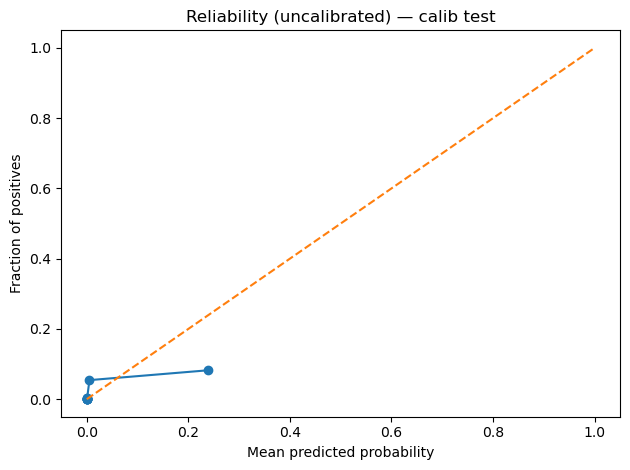

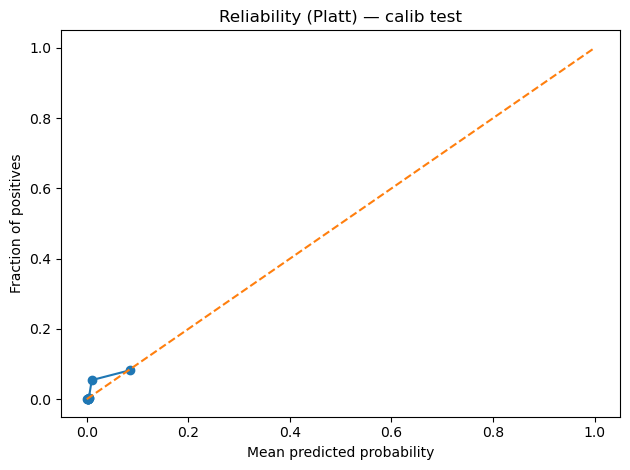

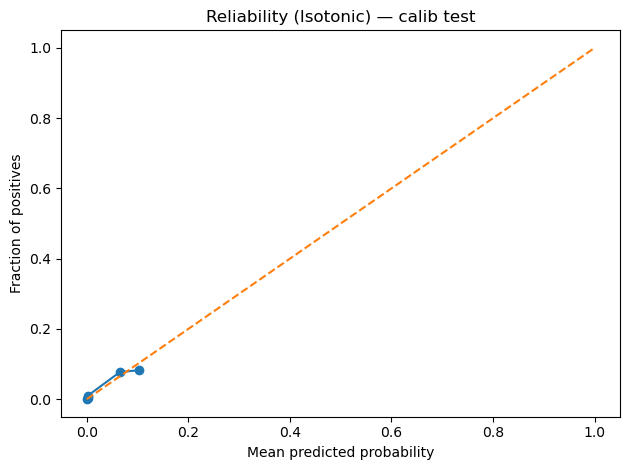

In [8]:
def plot_reliability(y_true, p_pred, title, fname):
    frac_pos, mean_pred = calibration_curve(y_true, p_pred, n_bins=10, strategy="quantile")
    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=200)
    plt.show()

plot_reliability(y_te, p_raw_te,   "Reliability (uncalibrated) — calib test", "reliability_uncalibrated.png")
plot_reliability(y_te, p_platt_te, "Reliability (Platt) — calib test",        "reliability_platt.png")
plot_reliability(y_te, p_iso_te,   "Reliability (Isotonic) — calib test",     "reliability_isotonic.png")


### 4) Choose a calibrator and calibrate ALL OOF rows
We pick the calibrator with best (Brier, then ECE) on calib test.
Then create `p_cal` for all rows and save.


In [9]:
candidates = [
    ("uncalibrated", lambda x: np.asarray(x, dtype=float)),
    ("platt", platt_transform),
    ("isotonic", iso_transform),
]

best_name, best_score = None, None
for name, _ in candidates:
    score = (report[name]["brier"], report[name]["ece10"])
    if best_score is None or score < best_score:
        best_name, best_score = name, score

print("Chosen calibrator:", best_name, "score:", best_score)

def apply_calibrator(p_in):
    if best_name == "uncalibrated":
        return np.asarray(p_in, dtype=float)
    if best_name == "platt":
        return platt_transform(p_in)
    if best_name == "isotonic":
        return iso_transform(p_in)
    raise ValueError("Unknown calibrator")

df["p_cal"] = apply_calibrator(df["p_oof"].values)

df.to_parquet(OUT_OOF_CAL, index=False)

report["chosen"] = best_name
OUT_CAL_REPORT.write_text(json.dumps(report, indent=2))

print("Saved:")
print(" -", OUT_OOF_CAL)
print(" -", OUT_CAL_REPORT)


Chosen calibrator: isotonic score: (0.01332122846967302, 0.0007701618174785346)
Saved:
 - F:\Project 3 Folder\project 3--ews\results\oof_with_calibration.parquet
 - F:\Project 3 Folder\project 3--ews\results\calibration_report.json


### 5) Alert policy (Policy A): First-crossing + lockout
Policy A:
- alert when `p_cal >= tau`
- after an alert, suppress further alerts for `lockout_hours`

We evaluate:
- patient-level detection rate (alert before onset)
- lead time distribution
- alarm burden (alerts per 100 patient-hours, and non-sepsis patient alert rate)


In [10]:
def policy_first_crossing_lockout(df_patient: pd.DataFrame, prob_col: str, tau: float, lockout_hours: int = 6):
    # Returns a list of ICULOS times when alerts fired
    g = df_patient.sort_values("ICULOS")
    alert_times = []
    next_allowed = -np.inf

    for t, prob in zip(g["ICULOS"].values, g[prob_col].values):
        if t < next_allowed:
            continue
        if prob >= tau:
            alert_times.append(float(t))
            next_allowed = float(t) + lockout_hours
    return alert_times

def evaluate_policy(df_all: pd.DataFrame, tau: float, lockout_hours: int = 6, prob_col: str = "p_cal"):
    total_hours = float(len(df_all))  # hourly rows
    patient_table = df_all.drop_duplicates("patient_id")[["patient_id", "sepsis_any"]]
    n_patients = int(patient_table.shape[0])
    n_sepsis = int(patient_table["sepsis_any"].sum())
    n_nonsepsis = int(n_patients - n_sepsis)

    sepsis_detected = 0
    lead_times = []
    lead_ge_1 = lead_ge_3 = lead_ge_6 = 0

    nonsepsis_alerted = 0
    total_alerts = 0

    for pid, g in df_all.groupby("patient_id", sort=False):
        sepsis_any = int(g["sepsis_any"].iloc[0])
        onset = g["event_iculos"].iloc[0]  # NaN if non-sepsis

        alert_times = policy_first_crossing_lockout(g, prob_col=prob_col, tau=tau, lockout_hours=lockout_hours)
        total_alerts += len(alert_times)

        if sepsis_any == 0:
            if len(alert_times) > 0:
                nonsepsis_alerted += 1
            continue

        # Sepsis patient
        if len(alert_times) == 0 or pd.isna(onset):
            continue

        first_alert = alert_times[0]
        lead = float(onset) - float(first_alert)
        lead_times.append(lead)

        if lead > 0:
            sepsis_detected += 1
        if lead >= 1: lead_ge_1 += 1
        if lead >= 3: lead_ge_3 += 1
        if lead >= 6: lead_ge_6 += 1

    alerts_per_100h = (total_alerts / total_hours) * 100.0

    return {
        "tau": float(tau),
        "lockout_hours": int(lockout_hours),
        "n_patients": n_patients,
        "n_sepsis": n_sepsis,
        "n_nonsepsis": n_nonsepsis,
        "sepsis_detected": int(sepsis_detected),
        "sepsis_detection_rate": float(sepsis_detected / n_sepsis) if n_sepsis else np.nan,
        "nonsepsis_alerted": int(nonsepsis_alerted),
        "nonsepsis_alert_rate": float(nonsepsis_alerted / n_nonsepsis) if n_nonsepsis else np.nan,
        "alerts_total": int(total_alerts),
        "alerts_per_100_patient_hours": float(alerts_per_100h),
        "lead_time_median": float(np.nanmedian(lead_times)) if len(lead_times) else np.nan,
        "lead_time_mean": float(np.nanmean(lead_times)) if len(lead_times) else np.nan,
        "lead_ge_1_rate": float(lead_ge_1 / n_sepsis) if n_sepsis else np.nan,
        "lead_ge_3_rate": float(lead_ge_3 / n_sepsis) if n_sepsis else np.nan,
        "lead_ge_6_rate": float(lead_ge_6 / n_sepsis) if n_sepsis else np.nan,
    }


### 6) Threshold sweep (Policy A) + tradeoff curves
We sweep `tau` and compute system-level tradeoffs.
Adjust `TAUS` if your probabilities are extremely small/large.


In [11]:
LOCKOUT_HOURS = 6

TAUS = np.unique(np.concatenate([
    np.linspace(0.01, 0.10, 20),
    np.linspace(0.10, 0.50, 17),
    np.linspace(0.50, 0.95, 10),
]))

sweep_rows = [evaluate_policy(df, tau=float(t), lockout_hours=LOCKOUT_HOURS, prob_col="p_cal") for t in TAUS]
sweep = pd.DataFrame(sweep_rows)

sweep.to_csv(OUT_SWEEP, index=False)
sweep.head()


,tau,lockout_hours,n_patients,n_sepsis,n_nonsepsis,sepsis_detected,sepsis_detection_rate,nonsepsis_alerted,nonsepsis_alert_rate,alerts_total,alerts_per_100_patient_hours,lead_time_median,lead_time_mean,lead_ge_1_rate,lead_ge_3_rate,lead_ge_6_rate
0,0.010000,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154
1,0.014737,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154
2,0.019474,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154
3,0.024211,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154
4,0.028947,6,493,39,454,39,1.0,5,0.011013,423,2.209454,63.0,66.102564,1.0,0.948718,0.846154


Saved: F:\Project 3 Folder\project 3--ews\figures\tradeoff_detection_vs_falsealert_symlog.png


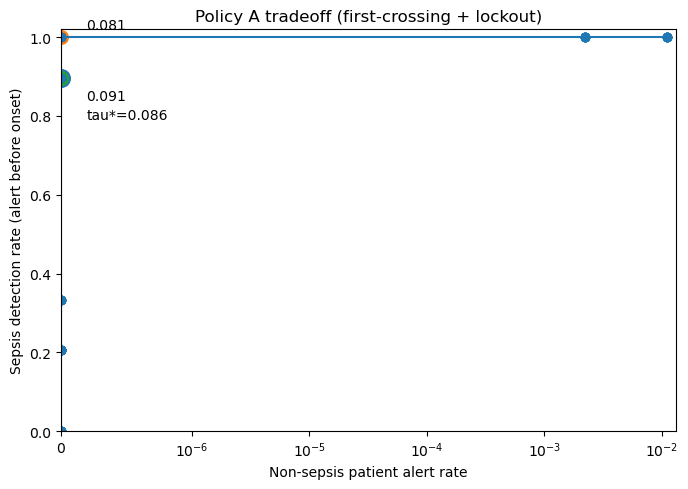

In [26]:
tau_star = float(TAU_STAR)

# Make sure sweep is sorted for neighbor selection
sweep_sorted = sweep.sort_values("tau").reset_index(drop=True)

# Find closest point to tau*
pos = int(np.argmin(np.abs(sweep_sorted["tau"].values - tau_star)))
neighbor_positions = [pos]
if pos - 1 >= 0:
    neighbor_positions.append(pos - 1)
if pos + 1 < len(sweep_sorted):
    neighbor_positions.append(pos + 1)

# Main curve
plt.figure(figsize=(7, 5))
plt.plot(
    sweep_sorted["nonsepsis_alert_rate"],
    sweep_sorted["sepsis_detection_rate"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Non-sepsis patient alert rate")
plt.ylabel("Sepsis detection rate (alert before onset)")
plt.title("Policy A tradeoff (first-crossing + lockout)")

# ✅ symlog + forced zoom
plt.xscale("symlog", linthresh=1e-6)

# Choose a zoom limit based on your data (so it always spreads points)
xmax = max(2e-3, float(np.nanpercentile(sweep_sorted["nonsepsis_alert_rate"], 99)) * 1.2)
plt.xlim(0, xmax)
plt.ylim(0, 1.02)

# Highlight tau* and neighbors with staggered labels
offsets = [(18, -22), (18, 14), (18, -8)]  # star, left, right (staggered)

for i, p in enumerate(neighbor_positions):
    tau_n = float(sweep_sorted.loc[p, "tau"])
    x_n = float(sweep_sorted.loc[p, "nonsepsis_alert_rate"])
    y_n = float(sweep_sorted.loc[p, "sepsis_detection_rate"])

    size = 160 if p == pos else 95
    plt.scatter([x_n], [y_n], s=size)

    label = f"tau*={tau_n:.3f}" if p == pos else f"{tau_n:.3f}"
    dx, dy = offsets[i % len(offsets)]
    plt.annotate(label, (x_n, y_n), textcoords="offset points", xytext=(dx, dy),
                 ha="left", va="top")

plt.tight_layout()

out_path = FIG_DIR / "tradeoff_detection_vs_falsealert_symlog.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved:", out_path)

plt.show()


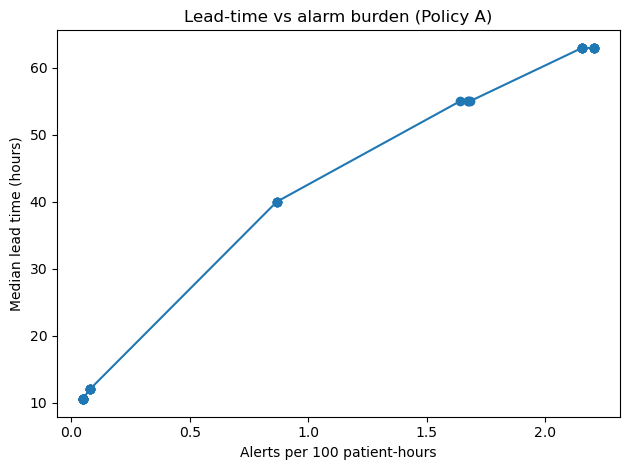

In [13]:
plt.figure()
plt.plot(sweep["alerts_per_100_patient_hours"], sweep["lead_time_median"], marker="o", linestyle="-")
plt.xlabel("Alerts per 100 patient-hours")
plt.ylabel("Median lead time (hours)")
plt.title("Lead-time vs alarm burden (Policy A)")
plt.tight_layout()
plt.savefig(FIG_DIR / "tradeoff_lead_vs_burden.png", dpi=200)
plt.show()


### 7) Choose an operating threshold (example constraint-based)
Example constraints (edit these):
- Non-sepsis alert rate ≤ 10%
- Alerts per 100 patient-hours ≤ 1.0


In [14]:
MAX_FALSE_ALERT = 0.10
MAX_ALERTS_PER_100H = 1.0

feasible = sweep[(sweep["nonsepsis_alert_rate"] <= MAX_FALSE_ALERT) &
                 (sweep["alerts_per_100_patient_hours"] <= MAX_ALERTS_PER_100H)].copy()

if feasible.empty:
    print("No thresholds meet constraints. Relax constraints or extend TAUS.")
    chosen = sweep.sort_values(["sepsis_detection_rate", "lead_time_median"], ascending=False).head(1)
else:
    chosen = feasible.sort_values(["sepsis_detection_rate", "lead_time_median"], ascending=False).head(1)

chosen


,tau,lockout_hours,n_patients,n_sepsis,n_nonsepsis,sepsis_detected,sepsis_detection_rate,nonsepsis_alerted,nonsepsis_alert_rate,alerts_total,alerts_per_100_patient_hours,lead_time_median,lead_time_mean,lead_ge_1_rate,lead_ge_3_rate,lead_ge_6_rate
16,0.085789,6,493,39,454,35,0.897436,0,0.0,166,0.867067,40.0,53.057143,0.897436,0.846154,0.717949


In [15]:
TAU_STAR = float(chosen["tau"].iloc[0])
print("Chosen tau* =", TAU_STAR)

chosen_metrics = evaluate_policy(df, tau=TAU_STAR, lockout_hours=LOCKOUT_HOURS, prob_col="p_cal")
chosen_metrics


Chosen tau* = 0.08578947368421053


{'tau': 0.08578947368421053,
 'lockout_hours': 6,
 'n_patients': 493,
 'n_sepsis': 39,
 'n_nonsepsis': 454,
 'sepsis_detected': 35,
 'sepsis_detection_rate': 0.8974358974358975,
 'nonsepsis_alerted': 0,
 'nonsepsis_alert_rate': 0.0,
 'alerts_total': 166,
 'alerts_per_100_patient_hours': 0.8670671193523114,
 'lead_time_median': 40.0,
 'lead_time_mean': 53.05714285714286,
 'lead_ge_1_rate': 0.8974358974358975,
 'lead_ge_3_rate': 0.8461538461538461,
 'lead_ge_6_rate': 0.717948717948718}

### 8) Lead-time distribution at tau*

Total sepsis patients: 39
Detected sepsis with positive lead: 35
Median lead=40.0h | IQR=(12.5,75.0)h | p95=176.3h | p99=199.6h | max=204.0h
% sepsis alerted with lead ≥ 1h: 0.897  (35/39)
% sepsis alerted with lead ≥ 3h: 0.846  (33/39)
% sepsis alerted with lead ≥ 6h: 0.718  (28/39)
Saved figure to: F:\Project 3 Folder\project 3--ews\figures\lead_time_hist_tau_star_0.086_zoom96.png


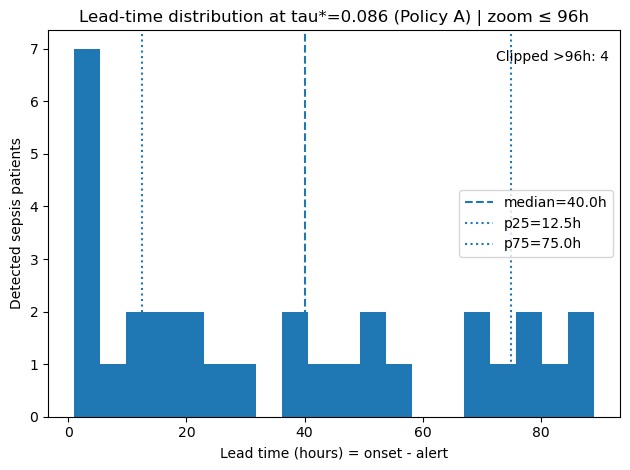

In [17]:
def lead_times_at_tau(df_all: pd.DataFrame, tau: float, lockout_hours: int = 6, prob_col: str = "p_cal"):
    """
    Returns lead times (onset - first_alert) for sepsis patients where the first alert occurs before onset.
    """
    leads = []
    for pid, g in df_all.groupby("patient_id", sort=False):
        if int(g["sepsis_any"].iloc[0]) == 0:
            continue

        onset = g["event_iculos"].iloc[0]
        if pd.isna(onset):
            continue

        alert_times = policy_first_crossing_lockout(g, prob_col=prob_col, tau=tau, lockout_hours=lockout_hours)
        if len(alert_times) == 0:
            continue

        lead = float(onset) - float(alert_times[0])
        if lead > 0:   # count only true early warnings
            leads.append(lead)

    return np.asarray(leads, dtype=float)

# --- Use your notebook variables (adjust only if your names differ) ---
tau_star = float(TAU_STAR)        # or use tau_star / TAU_STAR depending on your notebook
lockout_hours = int(LOCKOUT_HOURS)
prob_col = "p_cal"

leads = lead_times_at_tau(df, tau=tau_star, lockout_hours=lockout_hours, prob_col=prob_col)

# Denominator: ALL sepsis patients in cohort
n_sepsis_total = int(df.drop_duplicates("patient_id")["sepsis_any"].sum())
n_detected = int(len(leads))

print(f"Total sepsis patients: {n_sepsis_total}")
print(f"Detected sepsis with positive lead: {n_detected}")

if n_detected > 0:
    # Summary stats
    p50 = np.percentile(leads, 50)
    p25 = np.percentile(leads, 25)
    p75 = np.percentile(leads, 75)
    p95 = np.percentile(leads, 95)
    p99 = np.percentile(leads, 99)
    mx  = np.max(leads)

    print(f"Median lead={p50:.1f}h | IQR=({p25:.1f},{p75:.1f})h | p95={p95:.1f}h | p99={p99:.1f}h | max={mx:.1f}h")

    # Actionable windows: fraction of ALL sepsis patients (not only detected)
    n_ge_1 = int((leads >= 1).sum())
    n_ge_3 = int((leads >= 3).sum())
    n_ge_6 = int((leads >= 6).sum())

    print(f"% sepsis alerted with lead ≥ 1h: {n_ge_1/n_sepsis_total:.3f}  ({n_ge_1}/{n_sepsis_total})")
    print(f"% sepsis alerted with lead ≥ 3h: {n_ge_3/n_sepsis_total:.3f}  ({n_ge_3}/{n_sepsis_total})")
    print(f"% sepsis alerted with lead ≥ 6h: {n_ge_6/n_sepsis_total:.3f}  ({n_ge_6}/{n_sepsis_total})")

    # Plot: zoom so outliers don't hide the main story
    ZOOM_MAX = 96  # set 72/96/120 as you prefer
    leads_zoom = leads[leads <= ZOOM_MAX]
    n_clipped = int((leads > ZOOM_MAX).sum())

    plt.figure()
    plt.hist(leads_zoom, bins=20)
    plt.axvline(p50, linestyle="--", label=f"median={p50:.1f}h")
    plt.axvline(p25, linestyle=":", label=f"p25={p25:.1f}h")
    plt.axvline(p75, linestyle=":", label=f"p75={p75:.1f}h")

    plt.title(f"Lead-time distribution at tau*={tau_star:.3f} (Policy A) | zoom ≤ {ZOOM_MAX}h")
    plt.xlabel("Lead time (hours) = onset - alert")
    plt.ylabel("Detected sepsis patients")

    if n_clipped > 0:
        plt.text(
            0.98, 0.95,
            f"Clipped >{ZOOM_MAX}h: {n_clipped}",
            transform=plt.gca().transAxes,
            ha="right", va="top"
        )

    plt.legend()
    plt.tight_layout()
    out_path = FIG_DIR / f"lead_time_hist_tau_star_{tau_star:.3f}_zoom{ZOOM_MAX}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", out_path)
    plt.show()

else:
    print("No positive lead times at this tau — check tau*, onset, or policy implementation.")



## Done ✅
You now have:
- calibrated OOF probabilities (`p_cal`)
- a deployable alert policy (Policy A)
- threshold sweep + operating point
- lead-time & alarm burden analysis

Next (optional, PhD-level):
- Policy B: persistence (K-of-M) to reduce false alerts
- Utility-based thresholding (cost of FP/FN + delay)
- Subgroup calibration drift tests
